In [1]:
import pandas as pd
df = pd.read_csv('feature_eng_df_final.csv')

In [2]:
df.head()

,age,education,monthly_salary,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,...,affordability_ratio,credit_score_category,credit_score_numeric,combined_credit_risk,employment_tenure_category,is_long_term_employed,income_per_family_member,savings_to_income_ratio,credit_stability_score,loan_affordability_index
0,38.0,3.0,11.321777,0.641854,2.0,0.0,1.280128,3,2,0.0,...,-2.443993,Fair,2,3,Entry-level,0,3.773926,0.042580,423.623565,1.205905
1,38.0,1.0,9.975855,2.079442,4.0,1.0,-0.814566,2,1,5100.0,...,-513.331366,Good,1,2,Mid-level,1,4.987927,-0.177067,1484.721261,1.178826
2,38.0,3.0,11.363276,1.916923,0.0,2.0,-0.814566,4,3,0.0,...,-1.321418,Fair,2,2,Mid-level,1,2.840819,0.346565,1245.999698,1.111593
3,58.0,0.0,11.109473,1.163151,2.0,2.0,-0.814566,5,4,11400.0,...,-1027.461671,Good,1,1,Entry-level,0,2.221895,0.200884,796.758305,1.136398
4,48.0,3.0,10.956073,1.481605,2.0,1.0,-0.814566,4,3,9400.0,...,-859.501890,Excellent,0,0,Mid-level,0,2.739018,-0.153537,1140.835497,1.135187


In [3]:
len(df.columns)

45

In [4]:
df.select_dtypes(include='object').columns

Index(['age_group', 'credit_score_category', 'employment_tenure_category'], dtype='object')

In [5]:
# dropping credit score category since it already encoded as new column credit_score_numeric
df.drop('credit_score_category',axis=1,inplace=True)

In [6]:
#let's encode the binned age group column derived from age column in to ordinal encoder
df['age_group'].unique()
age_group_order = ['25-34','35-44', '45-54', '55-64']
from sklearn.preprocessing import OrdinalEncoder
age_group_encoder = OrdinalEncoder(categories=[age_group_order])
df['age_group'] = age_group_encoder.fit_transform(df[['age_group']])
print("after encoding df['age_group']",df['age_group'].unique())
df.drop('age',axis=1,inplace=True)

after encoding df['age_group'] [1. 3. 2. 0.]


In [7]:
#let encode binned employment experience type from year_of_employment column 
df['employment_tenure_category'].unique()
employment_order = ['Entry-level', 'Mid-level', 'Experienced']
emp_category_encoder = OrdinalEncoder(categories=[employment_order])
df['employment_tenure_category'] = emp_category_encoder.fit_transform(df[['employment_tenure_category']])
print("after encoding emp tenure category ",df['employment_tenure_category'].unique())
df.drop('years_of_employment',axis=1,inplace=True)

after encoding emp tenure category  [0. 1. 2.]


In [8]:
from sklearn.model_selection import train_test_split
X=df.drop(['emi_eligibility'],axis=1)
y=df['emi_eligibility']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(322243, 41)
(80561, 41)
(322243,)
(80561,)


In [9]:
df.columns

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'age_group', 'gender_FEMALE', 'gender_MALE',
       'marital_status_Married', 'marital_status_Single',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='ob

In [13]:
# Avoiding dummy traps
X_train.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)
X_test.drop(['gender_MALE','marital_status_Single','employment_type_Government'],axis=1,inplace=True)

In [10]:
#Prdeciting Features
X_train.drop(['max_monthly_emi'],axis=1,inplace=True)
X_test.drop(['max_monthly_emi'],axis=1,inplace=True)

In [11]:
#dropping functional duplicates...
columns_to_drop = ['monthly_rent','school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses']
X_train= X_train.drop(columns=columns_to_drop, axis=1)
X_test= X_test.drop(columns=columns_to_drop, axis=1)

In [14]:
print(X_train.columns)
print(len(X_train.columns))

Index(['education', 'monthly_salary', 'company_type', 'house_type',
       'family_size', 'dependents', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'age_group', 'gender_FEMALE',
       'marital_status_Married', 'employment_type_Private',
       'employment_type_Self-employed', 'debt_to_income_ratio',
       'total_expenses', 'expense_to_income_ratio', 'affordability_ratio',
       'credit_score_numeric', 'combined_credit_risk',
       'employment_tenure_category', 'is_long_term_employed',
       'income_per_family_member', 'savings_to_income_ratio',
       'credit_stability_score', 'loan_affordability_index'],
      dtype='object')
31


**1 .Checking count of each categorical target variable in train data**

Reason: Checking for class imbalance


Outcome : can take a decision on whether sampling is needed or not


In [14]:
y_train.value_counts()

emi_eligibility
2.0    249061
0.0     59265
1.0     13917
Name: count, dtype: int64

In [15]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,classification_report,confusion_matrix,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
# Set a tracking URI for MLflow. By default, it uses a local folder 'mlruns'.
# You can also set it to a database or a remote server.
# mlflow.set_tracking_uri("sqlite:///mlruns.db") # Example for a database

print(f"MLflow Version: {mlflow.__version__}")

MLflow Version: 3.9.0


### Training a Random Forest Classification Model

Let's assume you have your `X_train`, `X_test`, `y_train`, `y_test` data ready from previous steps.

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=400,               # 800 is overkill for 380k rows; 400 is efficient
    max_depth=15,                   # Explicitly cap depth to force generalization
    min_samples_leaf=100,           # Much higher! Prevents overfitting on the 249k majority
    max_features='sqrt',
    class_weight='balanced_subsample', # Better for multi-class imbalance
    bootstrap=True,
    max_samples=0.7,                # Each tree only sees 70% of the data to increase variety
    random_state=42,
    n_jobs=-1
)

In [17]:
rf_model.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)
# view metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average='macro')
print("accuracy --",accuracy)
print("precision---",precision)
print("recall score---",recall)
print("f1 score.----",f1)
print("roc_auc--",roc_auc)

accuracy -- 0.8088032670895346
precision--- 0.64328559745386
recall score--- 0.7559908550604179
f1 score.---- 0.6475466387015335
roc_auc-- 0.9069173651158801


In [19]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.77      0.77      0.77     14817
         1.0       0.17      0.67      0.27      3479
         2.0       0.99      0.83      0.90     62265

    accuracy                           0.81     80561
   macro avg       0.64      0.76      0.65     80561
weighted avg       0.91      0.81      0.85     80561



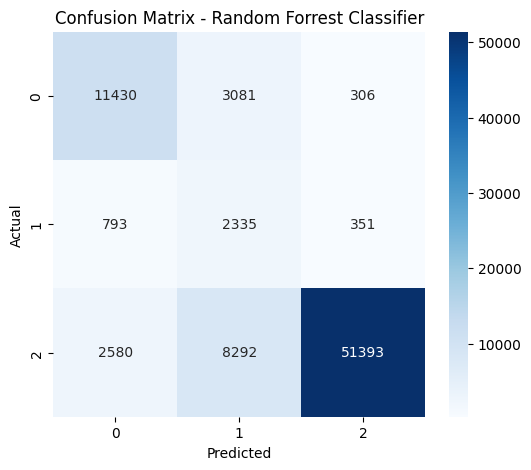

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forrest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

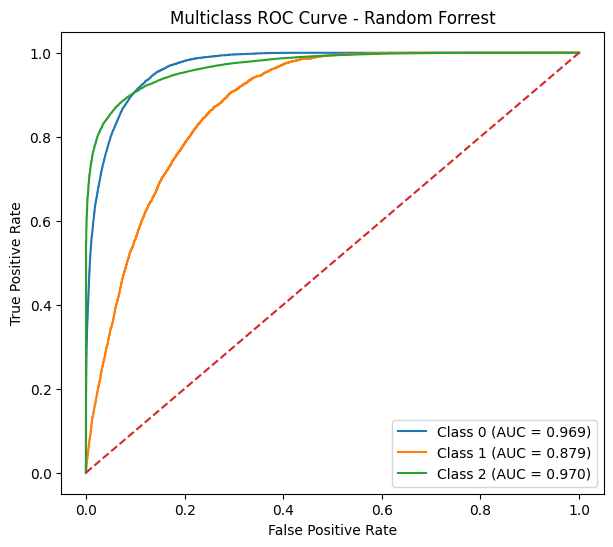

In [21]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Random Forrest")
plt.legend()
plt.show()

## Identifying Feature Importance

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


                     Feature  Importance
30  loan_affordability_index    0.274437
12          requested_amount    0.136462
13          requested_tenure    0.106029
1             monthly_salary    0.081053
22       affordability_ratio    0.057220
3                 house_type    0.047215
21   expense_to_income_ratio    0.041456
7         current_emi_amount    0.035714
19      debt_to_income_ratio    0.033517
6             existing_loans    0.029225


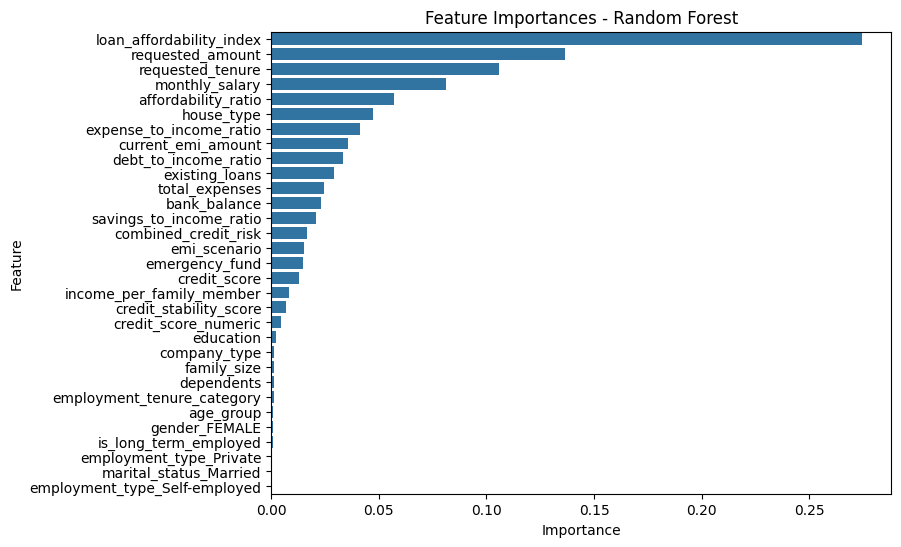

In [23]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importances - Random Forest")
plt.show()


## Train data evaluation.

In [24]:
x_predict_ = rf_model.predict(X_train)

In [25]:
# Make predictions
x_pred_prob = rf_model.predict_proba(X_train)
# view metrics
x_accuracy = accuracy_score(y_train,x_predict_)
x_precision = precision_score(y_train, x_predict_, average='macro')
x_recall = recall_score(y_train, x_predict_, average='macro')
x_f1 = f1_score(y_train, x_predict_, average='macro')
x_roc_auc = roc_auc_score(y_train, x_pred_prob, multi_class='ovo', average='macro')
print("accuracy --",x_accuracy)
print("precision---",x_precision)
print("recall score---",x_recall)
print("f1 score.----",x_f1)
print("roc_auc--",x_roc_auc)

accuracy -- 0.818627557464398
precision--- 0.6590641657671023
recall score--- 0.7974033059407395
f1 score.---- 0.6684034027704561
roc_auc-- 0.9324976817117362


In [26]:
print("\nClassification Report:\n")
print(classification_report(y_train,x_predict_))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79     59265
         1.0       0.20      0.77      0.31     13917
         2.0       0.99      0.83      0.90    249061

    accuracy                           0.82    322243
   macro avg       0.66      0.80      0.67    322243
weighted avg       0.92      0.82      0.86    322243



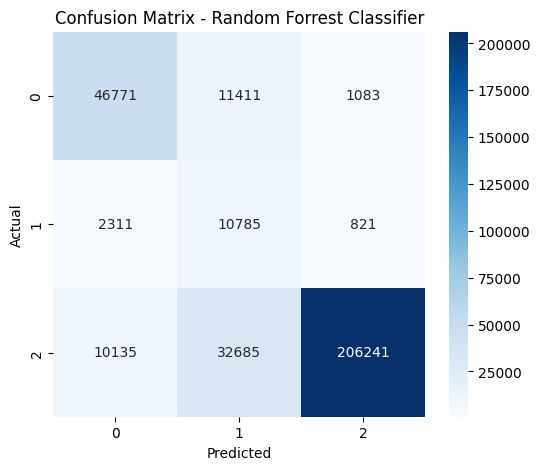

In [27]:
cm = confusion_matrix(y_train, x_predict_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forrest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

2026/02/24 22:44:22 INFO mlflow.tracking.fluent: Experiment with name 'EMI Eligibility Prediction Random Forrest Classification experiment' does not exist. Creating a new experiment.
2026/02/24 22:44:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\RAM\miniconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


🏃 View run clean-hog-52 at: http://127.0.0.1:5000/#/experiments/7/runs/f6181ed124a64778ad02f3b79fa158e8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


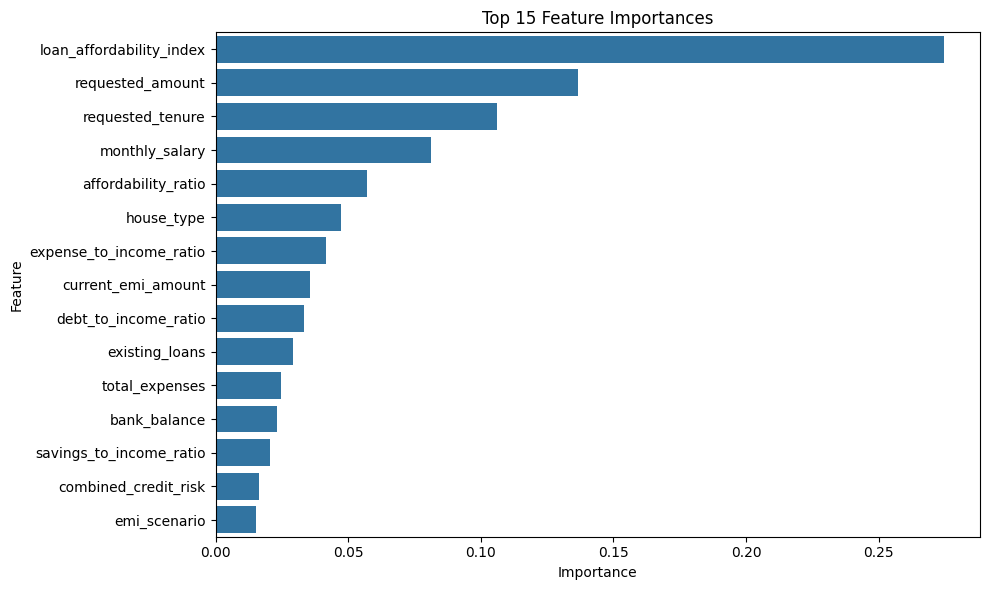

In [34]:
mlflow.set_experiment("EMI Eligibility Prediction Random Forrest Classification experiment")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
with mlflow.start_run():

    # ---------------------
    # Log Parameters
    # ---------------------
    mlflow.log_param("model_type", "Random Forest Classifier")
    params = {
    "n_estimators": 400,
    "max_depth": 15,
    "min_samples_leaf": 50,
    "max_features": 'sqrt',
    "class_weight": "balanced_subsample", # Recalculates weights per tree
    "random_state": 42,
    "n_jobs": -1
    }
    mlflow.log_params(params)

    # ---------------------
    # Log Metrics
    # ---------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1 score",f1)
    roc_auc_macro = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_pred_prob,
        average="macro"
    )
    mlflow.log_metric("roc_auc_macro", roc_auc_macro)

    # ---------------------
    # Confusion Matrix Plot
    # ---------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

    # ---------------------
    # ROC Curve (Multiclass)
    # ---------------------
    y_test_bin = label_binarize(y_test, classes=[0,1,2])

    plt.figure(figsize=(7,6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("Multiclass ROC Curve")
    plt.legend()

    plt.savefig("roc_curve.png")
    mlflow.log_artifact("roc_curve.png")
    plt.close()
   
    
    # 1. Log the DataFrame as a CSV Artifact
    csv_path = "feature_importance.csv"
    feature_importance.to_csv(csv_path, index=False)
    mlflow.log_artifact(csv_path)
    
    # 2. Log the Top 5 features as Metrics (for easy UI comparison)
    top_5 = feature_importance.head(5)
    for index, row in top_5.iterrows():
        # Replaces spaces with underscores for MLflow compatibility
        metric_name = f"feat_{row['Feature'].replace(' ', '_')}"
        mlflow.log_metric(metric_name, row['Importance'])

    # 3. Create and log a visual plot (The 'Quick Look')
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance.head(15))
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    
    plot_path = "feature_importance_plot.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)

    # ---------------------
    # Log Model
    # ---------------------
    mlflow.sklearn.log_model(rf_model, "random forrest model")
